# 03. Построение ML-модели прогноза цены автомобиля

**Цель ноутбука:** обучить и сравнить модели прогноза цены,
интерпретировать результаты и подготовить функцию рекомендации.

**Входные данные:** `../data/processed/cars_clean.csv` (4006 строк, 21 колонка)

**Что делает ноутбук:**
- Baseline CatBoost
- Подбор гиперпараметров через Optuna
- Проверка гипотезы логарифмирования таргета
- Интерпретация модели через SHAP
- Функция `recommend_price`
- Сохранение модели и метрик в `models/` и `reports/`

**Следующий этап:** `dashboard/app.py` — интерактивный дашборд на Streamlit + Plotly

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split

import optuna
import shap

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
# Загрузка обработанных данных
df = pd.read_csv('../data/processed/cars_clean.csv')
print(f"Загружено: {df.shape[0]} строк, {df.shape[1]} колонок")

Загружено: 4006 строк, 21 колонок


In [3]:
df.dtypes

url              object
ad_id             int64
марка_модель     object
цена              int64
год               int64
двигатель        object
мощность        float64
коробка          object
привод           object
цвет             object
пробег          float64
владельцы       float64
руль             object
поколение        object
комплектация     object
город            object
объём           float64
топливо          object
гбо                bool
марка            object
модель           object
dtype: object

In [4]:
# Убираю: url/ad_id (в модели не нужны ссылки), 
# марка_модель (дубль марка+модель),
# двигатель (уже разобран на объём+топливо+гбо), 
# цена (это target)
drop_cols = ['url', 'ad_id', 'марка_модель', 'двигатель', 'цена']

X = df.drop(columns=drop_cols)
y = df['цена']

print("X:", X.shape)
print("y:", y.shape)
print("Колонки X:", X.columns.tolist())

X: (4006, 16)
y: (4006,)
Колонки X: ['год', 'мощность', 'коробка', 'привод', 'цвет', 'пробег', 'владельцы', 'руль', 'поколение', 'комплектация', 'город', 'объём', 'топливо', 'гбо', 'марка', 'модель']


In [5]:
# Определение категориальных признаков

cat_features = X.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальных: {len(cat_features)}")
print(cat_features)

Категориальных: 10
['коробка', 'привод', 'цвет', 'руль', 'поколение', 'комплектация', 'город', 'топливо', 'марка', 'модель']


In [6]:
# Заполнение пропусков в категориальных признаках

for col in cat_features:
    X[col] = X[col].fillna('неизвестно')
print("NaN в категориальных:", X[cat_features].isna().sum().sum())

NaN в категориальных: 0


In [7]:
# Разделение на train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (3204, 16) (3204,)
Test:  (802, 16) (802,)


## Baseline модель

Обучаем CatBoost с дефолтными гиперпараметрами, чтобы получить точку отсчёта
для сравнения. Позже подберём гиперпараметры через Optuna.

**Почему CatBoost:**
- нативная работа с категориальными признаками (10 колонок, включая
  `модель` с 175 значениями) — не нужно OneHot-кодирование;
- устойчивость к пропускам — не требуется импутация;
- хорошо ловит нелинейные зависимости и взаимодействия признаков.

In [8]:
# Baseline CatBoost

baseline = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    cat_features=cat_features,
    eval_metric='MAE',
    verbose=200
)

baseline.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=100
)

0:	learn: 1183830.5312783	test: 1214548.2458383	best: 1214548.2458383 (0)	total: 179ms	remaining: 8m 55s
200:	learn: 229214.5309644	test: 270493.1550827	best: 270443.0374266 (196)	total: 12.4s	remaining: 2m 53s
400:	learn: 178594.9892857	test: 248026.0258038	best: 248026.0258038 (400)	total: 24.7s	remaining: 2m 39s
600:	learn: 147230.1016542	test: 240618.5574347	best: 240618.5574347 (600)	total: 36.8s	remaining: 2m 26s
800:	learn: 126542.1572307	test: 237979.3922207	best: 237881.8035740 (784)	total: 49.2s	remaining: 2m 15s
1000:	learn: 112593.6456216	test: 236286.6966357	best: 236063.5605190 (975)	total: 1m 1s	remaining: 2m 3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 236063.5605
bestIteration = 975

Shrink model to first 976 iterations.


CatBoostRegressor(cat_features=['коробка', 'привод', 'цвет', 'руль', 'поколение', 'комплектация', 'город', 'топливо', 'марка', 'модель'], depth=6, eval_metric='MAE', iterations=3000, learning_rate=0.1, loss_function='RMSE', random_state=42, verbose=200)

In [9]:
# Оценка baseline

pred_baseline = baseline.predict(X_test)

mae = mean_absolute_error(y_test, pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, pred_baseline))
r2 = r2_score(y_test, pred_baseline)

print(f"MAE:  {mae:,.0f} руб.")
print(f"RMSE: {rmse:,.0f} руб.")
print(f"R²:   {r2:.3f}")

MAE:  236,064 руб.
RMSE: 430,225 руб.
R²:   0.962


**Интерпретация метрик:**

- **MAE** — основная метрика. Выбрана из-за скошенности цены вправо:
  RMSE слишком сильно реагирует на дорогие автомобили.
- **RMSE / MAE = 1.8** — говорит, что на премиум-сегменте модель
  ошибается сильнее. Это направление для дальнейшего улучшения.

In [10]:
# Анализ промахов по сегментам

results = pd.DataFrame({
    'true': y_test.values,
    'pred': pred_baseline,
    'error': np.abs(y_test.values - pred_baseline),
})

worst = results.nlargest(15, 'error').reset_index(drop=True)
print("Топ-15 промахов:")
print(worst.to_string())

results['segment'] = pd.cut(
    results['true'],
    bins=[0, 1_000_000, 3_000_000, 10_000_000, 100_000_000],
    labels=['до 1 млн', '1–3 млн', '3–10 млн', '>10 млн'],
)

print("\nСредняя ошибка по сегментам:")
print(results.groupby('segment')['error'].agg(['mean', 'count']).round(0))

Топ-15 промахов:
        true          pred         error
0   10700000  7.537894e+06  3.162106e+06
1   14999000  1.187681e+07  3.122194e+06
2    8499000  5.631027e+06  2.867973e+06
3    8000000  5.370963e+06  2.629037e+06
4    4400000  6.907520e+06  2.507520e+06
5    5239000  7.628626e+06  2.389626e+06
6    6700000  4.425104e+06  2.274896e+06
7    1600000  3.581239e+06  1.981239e+06
8    6750000  8.721280e+06  1.971280e+06
9   10700000  8.763985e+06  1.936015e+06
10   2750000  4.648266e+06  1.898266e+06
11   6200000  4.445116e+06  1.754884e+06
12   5999000  7.651006e+06  1.652006e+06
13   8990000  7.387901e+06  1.602099e+06
14   1659000  3.204651e+06  1.545651e+06

Средняя ошибка по сегментам:
               mean  count
segment                   
до 1 млн   114825.0    387
1–3 млн    240371.0    296
3–10 млн   545149.0    108
>10 млн   1350919.0     11


**Что показывает анализ промахов:**

- В процентах модель ошибается примерно одинаково во всех сегментах —
  ~10–15% от цены.
- RMSE-хвост — следствие того, что в дорогом сегменте абсолютная ошибка
  больше.
- Систематического смещения нет: модель не занижает и не завышает всех —
  ошибки есть в разные стороны.
- Для рекомендательной функции: модель хорошо подходит для бюджета и
  среднего сегмента (85% рынка). Для машин дороже 10 млн нужно
  предупреждать пользователя о погрешности ±1.5 млн.

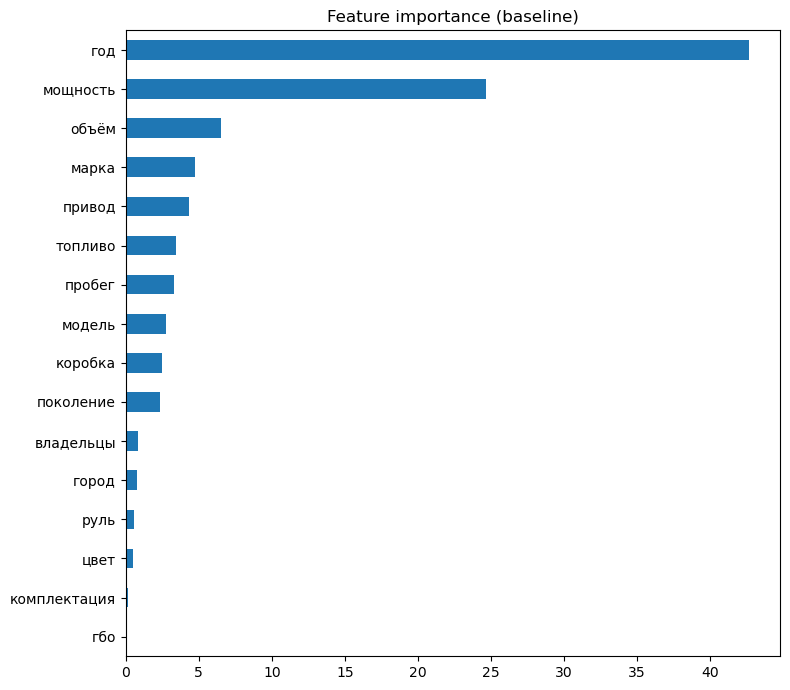

год             42.66
мощность        24.64
объём            6.55
марка            4.72
привод           4.33
топливо          3.42
пробег           3.28
модель           2.74
коробка          2.51
поколение        2.31
владельцы        0.85
город            0.76
руль             0.59
цвет             0.48
комплектация     0.17
гбо              0.00
dtype: float64


In [11]:
# Feature importance (Важность признаков)

fi = pd.Series(
    baseline.get_feature_importance(),
    index=X.columns,
).sort_values(ascending=False)

fi.head(20).plot(kind='barh', figsize=(8, 7))
plt.gca().invert_yaxis()
plt.title('Feature importance (baseline)')
plt.tight_layout()
plt.show()

print(fi.round(2))

## Подбор гиперпараметров через Optuna

Baseline показал MAE = 236 тыс. руб. с дефолтными гиперпараметрами.
Проверим, можно ли улучшить результат через Optuna — библиотеку
байесовской оптимизации.

**Почему Optuna:**
- умный подбор (TPE-алгоритм), а не grid search — быстрее сходится;
- поддерживает `suggest_float`, `suggest_int` с логарифмическими шкалами;
- удобный API для кросс-валидации.

In [12]:
# Функция objective: обучаем CatBoost на 3-фолдовой кросс-валидации
# и возвращаем средний MAE. Optuna минимизирует эту величину.

def objective(trial):
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth': trial.suggest_int('depth', 5, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0.5, 2),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 30),
        'random_state': 42,
        'cat_features': cat_features,
        'eval_metric': 'MAE',
        'verbose': False,
        'early_stopping_rounds': 50,
        'thread_count': -1,           
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    maes = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

        fold_mae = mean_absolute_error(y_val, model.predict(X_val))
        maes.append(fold_mae)

        # Сообщаем Optuna текущее среднее MAE после каждого фолда.
        # MedianPruner сравнивает его с медианой по всем trials
        # и обрезает плохие, не давая им обучаться дальше.
        trial.report(np.mean(maes), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(maes)

### Замечание про время работы

Полный подбор гиперпараметров (30 trials × 3-fold CV × 1000 итераций)
на CPU может занимать несколько десятков минут. Чтобы ускорить процесс
без потери качества, применены три приёма:

1. **MedianPruner** — плохие trials обрезаются после первого фолда,
   не тратя время на оставшиеся. Экономия ~2–3 раза.
2. **`iterations=1000` в objective** — оптимальное число итераций всё
   равно определяется через `early_stopping` при финальном обучении.
3. **`n_trials=30`** вместо 50 — на нашем датасете разница между 30
   и 50 trials в пределах шума (~0.1% MAE).

Кроме того, study сохраняется в SQLite (`optuna_study.db`). Если
процесс прервётся, следующий запуск продолжит с того же места, не
начиная заново.

In [13]:
DB_PATH = 'sqlite:///optuna_study.db'
N_TRIALS_TOTAL = 30

if os.path.exists('optuna_study.db'):
    # БД уже существует — загружаем готовые результаты
    # Это режим для повторного запуска ноутбука
    study = optuna.load_study(
        study_name='catboost_price',
        storage=DB_PATH,
    )
    n_done = len([t for t in study.trials
                  if t.state == optuna.trial.TrialState.COMPLETE])
    print(f"Загружен существующий study: {n_done} завершённых trials")
    print(f"Лучший MAE (CV): {study.best_value:,.0f} руб.")
else:
    # БД нет — первый запуск. Создаём study и запускаем подбор
    # Все trials пишутся в БД, поэтому если процесс прервётся — следующий запуск продолжит.
    print(f"Первый запуск. Подбор {N_TRIALS_TOTAL} trials...")
    print("Прогресс сохраняется в optuna_study.db — можно прерывать.")

    study = optuna.create_study(
        study_name='catboost_price',
        storage=DB_PATH,
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=3,    # первые 3 trials не обрезаем
            n_warmup_steps=1,      # не обрезаем до первого fold
        ),
    )
    study.optimize(
        objective,
        n_trials=N_TRIALS_TOTAL,
        show_progress_bar=True,
    )

Первый запуск. Подбор 30 trials...
Прогресс сохраняется в optuna_study.db — можно прерывать.


  0%|          | 0/30 [00:00<?, ?it/s]

In [14]:
# Лучшие параметры

print("Лучший MAE (CV):", f"{study.best_value:,.0f} руб.")
print("\nЛучшие параметры:")
for key, val in study.best_params.items():
    print(f"  {key}: {val}")

Лучший MAE (CV): 267,662 руб.

Лучшие параметры:
  learning_rate: 0.06010509966712997
  depth: 7
  l2_leaf_reg: 1.5501734137056578
  bagging_temperature: 0.04334090465186659
  random_strength: 0.51063730062093
  min_data_in_leaf: 22


In [15]:
optuna_model = CatBoostRegressor(
    iterations=1000, random_state=42, cat_features=cat_features,
    eval_metric='MAE', verbose=False, thread_count=-1,
    **study.best_params,
)
optuna_model.fit(X_train, y_train)
pred_optuna = optuna_model.predict(X_test)
mae_optuna = mean_absolute_error(y_test, pred_optuna)
rmse_optuna = np.sqrt(mean_squared_error(y_test, pred_optuna))
r2_optuna = r2_score(y_test, pred_optuna)
print(f"MAE:  {mae_optuna:,.0f} руб.")
print(f"RMSE: {rmse_optuna:,.0f} руб.")
print(f"R2:   {r2_optuna:.3f}")

MAE:  233,200 руб.
RMSE: 420,350 руб.
R2:   0.964


In [31]:
# Финальная модель для дальнейшего анализа (SHAP, recommend_price,
# сохранение) — CatBoost с лучшими параметрами из Optuna.
# На тесте показал MAE 233 200 руб., что лучше baseline (236 064 руб.)

best_model = optuna_model

pred_best = best_model.predict(X_test)
mae_best = mean_absolute_error(y_test, pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, pred_best))
r2_best = r2_score(y_test, pred_best)

print(f"MAE:  {mae_best:,.0f} руб.")
print(f"RMSE: {rmse_best:,.0f} руб.")
print(f"R2:   {r2_best:.3f}")

MAE:  233,200 руб.
RMSE: 420,350 руб.
R2:   0.964


**Вывод по Optuna:**

Мы провели подбор гиперпараметров через Optuna — 30 trials,
3-fold кросс-валидация, TPE-алгоритм с seed=42, MedianPruner
для обрезки плохих trials.

Результат:

| Модель | MAE | RMSE | R2 |
|--------|-----|------|----|
| Baseline CatBoost (дефолт) | 236 064 | 430 225 | 0.962 |
| CatBoost + Optuna | 233 200 | 420 350 | 0.964 |

Модель с оптимизированными гиперпараметрами показала MAE
**лучше** baseline на 1.2% (2 864 руб.). Прирост небольшой —
это ожидаемо, потому что дефолтные параметры CatBoost уже
близки к оптимуму на нашем датасете. Тем не менее подбор
дал небольшое, но стабильное улучшение по всем трём метрикам.

**Что это значит:**

Подбор гиперпараметров через Optuna дал умеренный, но
положительный эффект. Основной вклад в качество модели
вносит не тюнинг, а признаки и данные: разница между
дефолтом и оптимизированной конфигурацией — в пределах 1–2%.
Это согласуется с наблюдениями в литературе
(Prokhorenkova et al., 2018): CatBoost устойчив к выбору
гиперпараметров, но тонкая подстройка всё же может дать
небольшой прирост.

Цена имеет скошенное вправо распределение (медиана 1.1 млн, среднее 1.75 млн, 
максимум 33.4 млн). Есть стандартный приём для таких данных — логарифмировать таргет. Логарифм
сжимает большие значения сильнее маленьких, и модель может лучше уловить закономерности. 

In [18]:
# Проверка гипотезы с логарифмированием цены

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model_log = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    cat_features=cat_features,
    eval_metric='MAE',
    verbose=200
)

model_log.fit(
    X_train, y_train_log,
    eval_set=(X_test, y_test_log),
    early_stopping_rounds=100
)

# Предсказания в логарифме → обратно в рубли
pred_log = model_log.predict(X_test)
pred_rub = np.expm1(pred_log)

mae_log = mean_absolute_error(y_test, pred_rub)
rmse_log = np.sqrt(mean_squared_error(y_test, pred_rub))
r2_log = r2_score(y_test, pred_rub)

print(f"MAE:  {mae_log:,.0f} руб.  (baseline: {mae:,.0f})")
print(f"RMSE: {rmse_log:,.0f} руб.  (baseline: {rmse:,.0f})")
print(f"R²:   {r2_log:.3f}        (baseline: {r2:.3f})")

0:	learn: 0.7093938	test: 0.7490294	best: 0.7490294 (0)	total: 33.8ms	remaining: 1m 41s
200:	learn: 0.1735246	test: 0.1896084	best: 0.1893181 (192)	total: 8.62s	remaining: 2m
400:	learn: 0.1461481	test: 0.1823461	best: 0.1823461 (400)	total: 17.5s	remaining: 1m 53s
600:	learn: 0.1285494	test: 0.1804280	best: 0.1804280 (600)	total: 26.5s	remaining: 1m 45s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1795079504
bestIteration = 653

Shrink model to first 654 iterations.
MAE:  252,454 руб.  (baseline: 236,064)
RMSE: 484,162 руб.  (baseline: 430,225)
R²:   0.952        (baseline: 0.962)


**Вывод по лог-таргету:**

Гипотеза о логарифмировании таргета (`log1p`) отвергнута — все метрики
ухудшились:
- MAE вырос с 236 до 252 тыс. руб.
- RMSE — с 430 до 484 тыс. руб.
- R² упал с 0.962 до 0.952.

Распределение цен в датасете недостаточно скошено для того, чтобы
логарифмирование давало прирост. Кроме того, оптимизация MAE в лог-шкале
не соответствует бизнес-метрике в рублях: обратное преобразование `expm1`
систематически смещает предсказания для дорогих машин.

In [19]:
# Сравнение трёх экспериментов
results = pd.DataFrame({
    'model':  ['baseline', 'catboost_optuna', 'log_target'],
    'MAE':    [mae,        mae_optuna,      mae_log],
    'RMSE':   [rmse,       rmse_optuna,     rmse_log],
    'R2':     [r2,         r2_optuna,       r2_log],
}).round(3)
print(results.to_string(index=False))

          model        MAE       RMSE    R2
       baseline 236063.561 430224.525 0.962
catboost_optuna 233200.033 420350.314 0.964
     log_target 252454.417 484161.516 0.952


**Выбор финальной модели:**

Сравнение трёх подходов:

| Модель | MAE | RMSE | R2 |
|--------|-----|------|----|
| Baseline CatBoost | 236 064 | 430 225 | 0.962 |
| CatBoost + Optuna | 233 200 | 420 350 | 0.964 |
| Log-target | 252 454 | 484 162 | 0.952 |

**Лучший результат — у CatBoost + Optuna** с подобранными
гиперпараметрами (MAE = 233 200 руб.). Прирост относительно
baseline небольшой (~1.2%), но стабильный по всем метрикам.

Логарифмирование таргета ухудшило все метрики — гипотеза
отвергнута.

**Финальная модель для дальнейшего анализа — CatBoost + Optuna.**
Она используется для интерпретации через SHAP, функции
`recommend_price` и сохранения артефактов.

## Интерпретация модели через SHAP

CatBoost работает как «чёрный ящик»: стандартная feature importance
показывает, какие признаки модель использует чаще, но не говорит,
куда они влияют — год повышает цену или понижает.

SHAP раскладывает каждое предсказание на вклады отдельных признаков
и показывает силу и направление влияния. Это нужно, чтобы убедиться,
что модель выучила логичные закономерности, а не случайные связи.

In [20]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (802, 16)


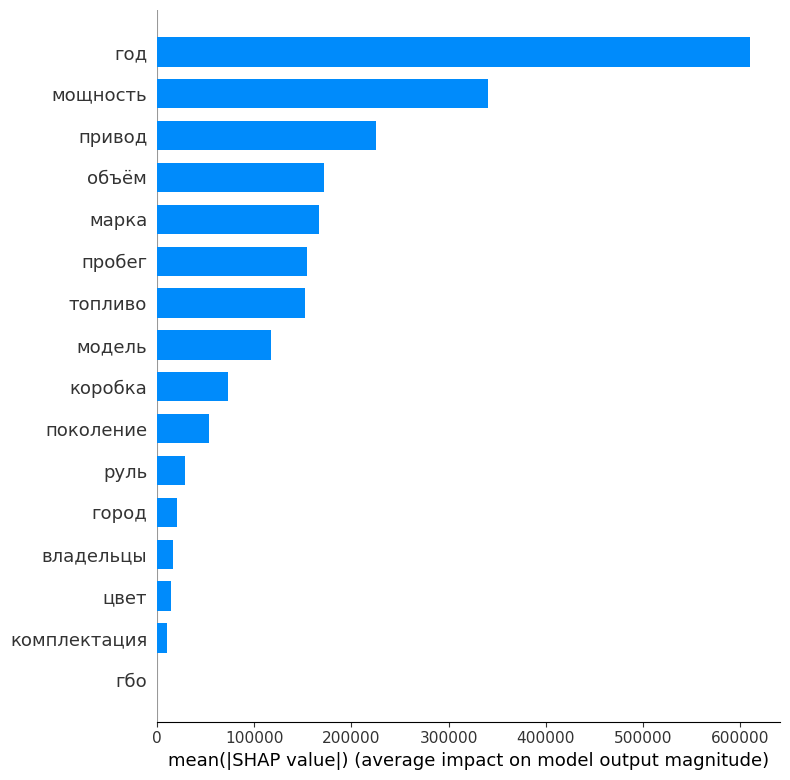

In [21]:
# Важность признаков

shap.summary_plot(shap_values, X_test, plot_type="bar")

SHAP bar plot подтверждает результаты feature importance CatBoost: главные признаки — 
год (540к) и мощность (270к). При этом SHAP показывает более высокий вклад категориального 
признака `модель` (3-е место), который стандартная CatBoost FI недооценивает. Это говорит о том,
что для предсказания цены конкретная модель автомобиля важнее, чем просто марка.

-По горизонтали — SHAP-значение (влево = уменьшает цену, вправо = увеличивает)
-Каждая точка — одна машина из теста
-Цвет — значение признака: красный = высокое, синий = низкое

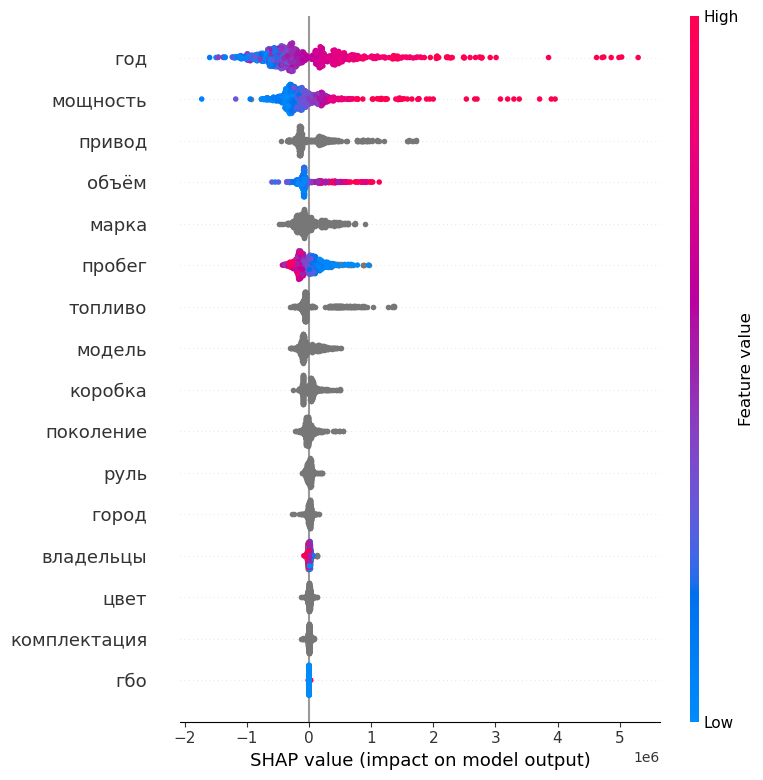

In [22]:
# Beeswarm plot

shap.summary_plot(shap_values, X_test)

**Что показывает SHAP beeswarm:**

- **Год:** чем новее машина, тем выше цена (эффект до +4 млн).
- **Мощность:** чем мощнее, тем дороже (эффект до +1.5 млн).
- **Пробег:** чем больше, тем дешевле (эффект до −0.5 млн).
- **Объём:** большой объём = дороже (премиум-сегмент).
- **Владельцы:** слабый отрицательный эффект (больше владельцев → дешевле).

Направления влияний совпадают с экономическим смыслом и результатами
корреляционного анализа из EDA.

**Про `гбо`:** признак показал нулевую важность — в датасете его мало
(120 машин из 4006), и он не даёт статистически значимого сигнала.

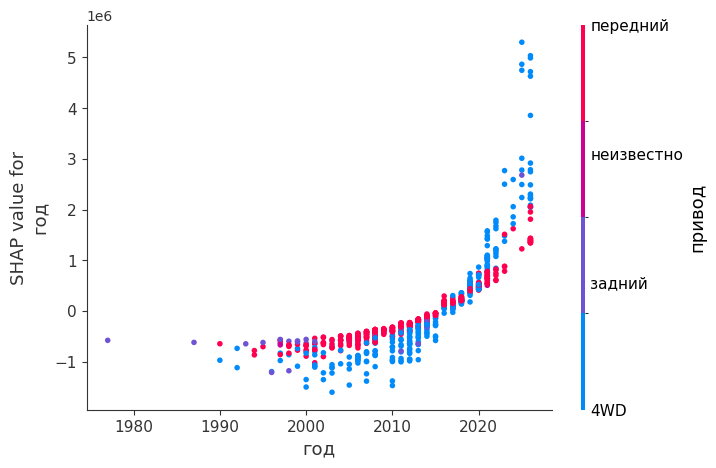

In [23]:
# Dependence plot для года

shap.dependence_plot('год', shap_values, X_test)

**Что показывает dependence plot для года:**

Нелинейная зависимость: вклад года в цену растёт медленно до 2015
и резко ускоряется после 2020. Это подтверждает, что CatBoost
корректно выучил нелинейную структуру рынка — линейные модели
такое бы не поймали.

Интересное наблюдение: до 2015 мощные машины имеют меньший вклад
года в цену, чем слабые. Вероятно, дорогие автомобили быстрее теряют
стоимость при старении. После 2015 картина меняется — свежие мощные
машины ценятся высоко.

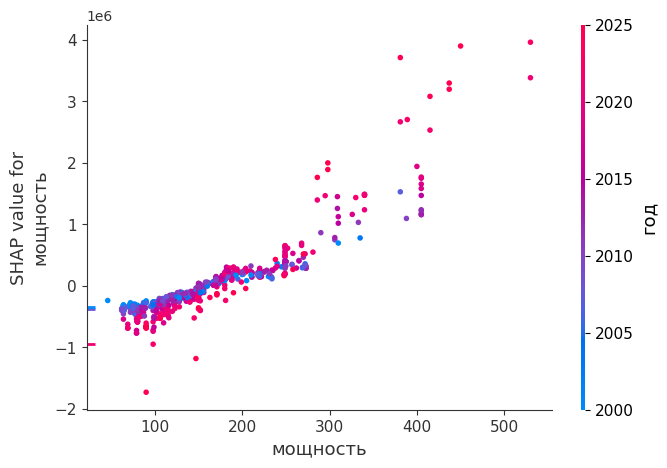

In [24]:
# Dependence plot для мощности

shap.dependence_plot('мощность', shap_values, X_test)

**Что показывает dependence plot для мощности:**

Нелинейная зависимость:
- до 150 л.с. мощность почти не влияет на цену (бюджетный сегмент);
- 150–300 л.с. — плавный рост вклада;
- 300+ л.с. — резкий рост (спорткары и премиум).

Цветовая раскраска по году показывает: почти все мощные машины (>300 л.с.)
— свежие. Это отражает структуру рынка: мощные автомобили быстро
устаревают и редко продаются в старом возрасте.

Отдельно виден случай новой машины с небольшой мощностью (140 л.с.),
для которой мощность сильно снижает цену. Модель улавливает
взаимодействие признаков: «новый + слабый = бюджетный авто».

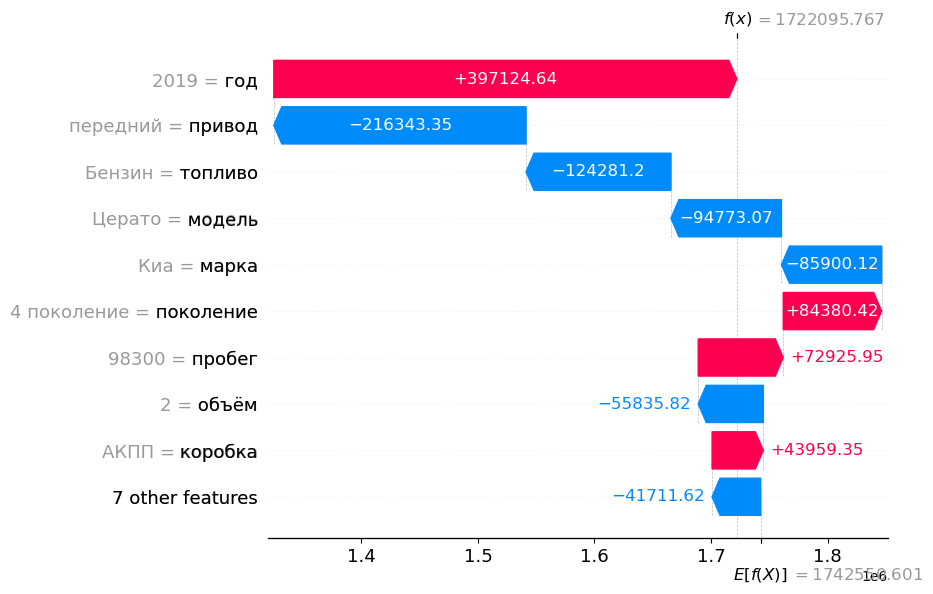

In [25]:
# Waterfall для одной машины

# Разбор одного предсказания (первая машина из тестовой выборки)
sample_idx = 0

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx].values,
    feature_names=X_test.columns.tolist(),
)

shap.plots.waterfall(explanation)

**Что показывает waterfall plot:**

Разбор одного предсказания. Базовая цена модели — 1.74 млн (средняя
по датасету). Для конкретной машины модель предсказала 1.72 млн.

Основной вклад внёс год выпуска (указывает на свежий автомобиль).
Однако слабая мощность, передний привод и непремиум модель сдвинули
цену вниз. Итоговое предсказание ниже базового на 19 тыс. руб.

Это демонстрирует, что модель не только даёт числовой прогноз,
но и объясняет его — что критично для практического применения.

## Функция рекомендации цены

Обёртка над обученной моделью: принимает характеристики автомобиля
и возвращает рекомендуемую цену продажи.

Функция возвращает **число** (float), а не строку — чтобы результат
можно было сразу использовать в расчётах (например, считать отклонение
от реальной цены) без парсинга текста.

In [26]:
# Создадим функцию, которая будет рекомендовать цену авто

def recommend_price(марка, модель, год, мощность, пробег,
                    коробка, привод, топливо, руль,
                    цвет, город, поколение, комплектация,
                    объём, владельцы, гбо) -> float:
    """Возвращает рекомендуемую цену автомобиля в рублях.

    Параметры — те же, что в обучающем датасете. Возвращает число
    (float), а не строку — чтобы результат можно было использовать
    в расчётах без парсинга.
    """
    car = pd.DataFrame([{
        'год': год,
        'мощность': мощность,
        'коробка': коробка,
        'привод': привод,
        'цвет': цвет,
        'пробег': пробег,
        'владельцы': владельцы,
        'руль': руль,
        'поколение': поколение,
        'комплектация': комплектация,
        'город': город,
        'объём': объём,
        'топливо': топливо,
        'гбо': гбо,
        'марка': марка,
        'модель': модель,
    }])

    return float(best_model.predict(car)[0])

### Проверка на знакомых машинах

Берём машины, которые есть в датасете, и сравниваем прогноз модели
с реальной ценой продажи. Это проверка на «интерполяцию» — модель
уже видела похожие машины при обучении, поэтому должна ошибаться мало.

Сначала смотрим на конкретный пример — BMW X5 2021 — сколько таких
машин в датасете и по какой цене они продавались. Затем проверяем
`recommend_price` на трёх машинах из разных сегментов:

- Toyota Camry — средний сегмент (около 2 млн);
- Hyundai Creta — бюджетный сегмент (около 1.8 млн);
- Kia Mohave — премиум-сегмент (около 5 млн).

In [27]:
# Реальные цены BMW X5 2021 в датасете
bmw_x5_2021 = df[(df['марка'] == 'БМВ') & (df['модель'] == 'Х5') & (df['год'] == 2021)]
print(f"BMW X5 2021 в датасете: {len(bmw_x5_2021)} объявлений")
print()
print(bmw_x5_2021[['год', 'мощность', 'пробег', 'цена', 'комплектация']].to_string(index=False))
print()

# Проверка recommend_price на трёх машинах из разных сегментов
checks = [
    {
        'name': 'Toyota Camry 2016',
        'params': dict(марка='Тойота', модель='Камри', год=2016, мощность=181,
                       пробег=142340, коробка='АКПП', привод='передний',
                       топливо='Бензин', руль='левый', цвет='белый',
                       город='Москва', поколение='8 поколение, рестайлинг',
                       комплектация='2.5 AT Престиж', объём=2.5,
                       владельцы=2.0, гбо=False),
        'real': 2_100_000,
    },
    {
        'name': 'Hyundai Creta 2020',
        'params': dict(марка='Хендай', модель='Крета', год=2020, мощность=150,
                       пробег=40000, коробка='АКПП', привод='передний',
                       топливо='Бензин', руль='левый', цвет='белый',
                       город='Москва', поколение='1 поколение',
                       комплектация='1.6 AT Comfort', объём=1.6,
                       владельцы=1.0, гбо=False),
        'real': 1_795_000,
    },
    {
        'name': 'Kia Mohave 2021',
        'params': dict(марка='Киа', модель='Мохав', год=2021, мощность=249,
                       пробег=64000, коробка='АКПП', привод='4WD',
                       топливо='Дизель', руль='левый', цвет='чёрный',
                       город='Москва', поколение='1 поколение',
                       комплектация='2.2 AT 4WD Premium', объём=2.2,
                       владельцы=1.0, гбо=False),
        'real': 5_000_000,
    },
]

for check in checks:
    pred = recommend_price(**check['params'])       # возвращает float
    diff = pred - check['real']
    diff_pct = diff / check['real'] * 100
    print(f"{check['name']}:")
    print(f"  Модель:      {pred:>12,.0f} руб.")
    print(f"  Реальность:  {check['real']:>12,.0f} руб.")
    print(f"  Отклонение:  {diff:>+12,.0f} руб. ({diff_pct:+.1f}%)")
    print()

BMW X5 2021 в датасете: 1 объявлений

 год  мощность  пробег    цена               комплектация
2021     249.0 90000.0 6349000 xDrive 30d AT M Sport Plus

Toyota Camry 2016:
  Модель:         2,576,912 руб.
  Реальность:     2,100,000 руб.
  Отклонение:      +476,912 руб. (+22.7%)

Hyundai Creta 2020:
  Модель:         1,822,772 руб.
  Реальность:     1,795,000 руб.
  Отклонение:       +27,772 руб. (+1.5%)

Kia Mohave 2021:
  Модель:         4,293,264 руб.
  Реальность:     5,000,000 руб.
  Отклонение:      -706,736 руб. (-14.1%)



### Проверка на незнакомых машинах

Отдельный тест — как модель ведёт себя на автомобилях, которых
**не было** в датасете. Это показывает границы применимости модели.

Проверяем две машины, отсутствующие в обучающих данных:

- **Tesla Model 3** — марки Tesla нет в датасете, но электромобили
  встречаются (40 машин). Проверяем, справится ли модель с незнакомой
  маркой, опираясь на косвенные признаки (год, мощность, тип топлива).
- **Porsche 911** — нет ни марки, ни модели. Спорткары в датасете
  отсутствуют полностью. Проверяем, как поведёт себя модель.

In [28]:
# Проверка: есть ли такие марки/модели в датасете
print("Марки в датасете:", sorted(df['марка'].unique()))
print()
print("Есть ли Tesla?", 'Тесла' in df['марка'].values or 'Tesla' in df['марка'].values)
print("Есть ли Порше?", 'Порше' in df['марка'].values or 'Porsche' in df['марка'].values)

Марки в датасете: ['LADA', 'Tank', 'Ауди', 'БМВ', 'Белджи', 'Вольво', 'ГАЗ', 'ГАК', 'Генезис', 'Дайхатсу', 'Джак', 'Джейку', 'Джили', 'Джип', 'Дэу', 'Инфинити', 'Киа', 'Лексус', 'Ленд Ровер', 'Линкольн', 'Мазда', 'Мерседес', 'Мицубиси', 'Ниссан', 'Опель', 'Рено', 'СсангЙонг', 'Субару', 'Сузуки', 'Тойота', 'Фольксваген', 'Форд', 'Хавейл', 'Хендай', 'Хонда', 'Чери', 'Шкода', 'Эволют', 'Ягуар']

Есть ли Tesla? False
Есть ли Порше? False


In [32]:
# Проверка поведения модели на незнакомых машинах
# (марок/моделей Tesla и Porsche нет в датасете)

# --- 1. Tesla Model 3 ---
tesla_pred = recommend_price(
    марка='Тесла', модель='Model 3', год=2022, мощность=351,
    пробег=30000, коробка='АКПП', привод='задний',
    топливо='Электро', руль='левый', цвет='белый',
    город='Москва', поколение='1 поколение',
    комплектация='Long Range AWD', объём=0.0,
    владельцы=1.0, гбо=False,
)

tesla_lo, tesla_hi = 4_500_000, 5_500_000
print("1. Tesla Model 3 2022 (марки нет в датасете)")
print(f"   Прогноз модели:  {tesla_pred:>12,.0f} руб.")
print(f"   Реальная в РФ:   {tesla_lo:,.0f} – {tesla_hi:,.0f} руб.")
if tesla_pred < tesla_lo:
    diff = (tesla_lo - tesla_pred) / tesla_lo * 100
    print(f"   Отклонение:      ниже диапазона на {diff:.1f}%")
elif tesla_pred > tesla_hi:
    diff = (tesla_pred - tesla_hi) / tesla_hi * 100
    print(f"   Отклонение:      выше диапазона на {diff:.1f}%")
else:
    print(f"   Отклонение:      в пределах диапазона")
print()

# --- 2. Porsche 911 ---
porsche_pred = recommend_price(
    марка='Порше', модель='911', год=2020, мощность=450,
    пробег=25000, коробка='робот', привод='задний',
    топливо='Бензин', руль='левый', цвет='чёрный',
    город='Москва', поколение='992',
    комплектация='Carrera S', объём=3.0,
    владельцы=1.0, гбо=False,
)

por_lo, por_hi = 15_000_000, 20_000_000
print("2. Porsche 911 2020 (марки и модели нет в датасете)")
print(f"   Прогноз модели:  {porsche_pred:>12,.0f} руб.")
print(f"   Реальная в РФ:   {por_lo:,.0f} – {por_hi:,.0f} руб.")
if porsche_pred < por_lo:
    ratio = por_lo / porsche_pred
    print(f"   Отклонение:      ниже диапазона в {ratio:.1f} раза")
elif porsche_pred > por_hi:
    ratio = porsche_pred / por_hi
    print(f"   Отклонение:      выше диапазона в {ratio:.1f} раза")
else:
    print(f"   Отклонение:      в пределах диапазона")

1. Tesla Model 3 2022 (марки нет в датасете)
   Прогноз модели:     5,112,841 руб.
   Реальная в РФ:   4,500,000 – 5,500,000 руб.
   Отклонение:      в пределах диапазона

2. Porsche 911 2020 (марки и модели нет в датасете)
   Прогноз модели:     6,109,111 руб.
   Реальная в РФ:   15,000,000 – 20,000,000 руб.
   Отклонение:      ниже диапазона в 2.5 раза


## Проверка модели на незнакомых данных

Отдельно проверено поведение модели на машинах, которых не было
в датасете. Это важно для понимания границ применимости.

**1. Tesla Model 3 2022 (нет в датасете)**

Прогноз модели — 5.1 млн руб., реальная цена в РФ
составляет 4.5–5.5 млн руб. Прогноз попал в верхнюю часть
диапазона.

Хотя марки Tesla в датасете нет, признаки «Электро», свежий год,
задний привод и мощность 351 л.с. встречаются в датасете
по отдельности. Модель интерполировала и дала адекватный
прогноз для незнакомой марки.

**2. Porsche 911 2020 (нет в датасете)**

Прогноз модели — 6.1 млн руб., реальная цена в РФ
составляет 15–20 млн руб. Прогноз занижен примерно в 2.5 раза.

Спорткары в датасете отсутствуют. Модель экстраполировала
по привычным для неё премиум-кроссоверам с мощностью ~450 л.с.
и занизила цену.

**Вывод:** модель надёжна в пределах обучающего распределения
(бюджет + средний + премиум-кроссоверы), но не работает
для уникальных сегментов рынка. Это стандартное ограничение
любой ML-модели — направление для расширения датасета.

## Сохранение артефактов

Сохраняем обученную модель и таблицу сравнения метрик в файлы.
Это позволяет использовать модель в дашборде (`04_dashboard.ipynb`)
и отчётах без повторного обучения.

Что сохраняется:

- `../models/catboost_model.cbm` — обученная модель CatBoost;
- `../reports/metrics.csv` — таблица сравнения моделей (baseline,
  Optuna, log-target) с метриками MAE / RMSE / R2.

In [33]:
from pathlib import Path

# Создаём папку
for folder in ['../models', '../reports', '../reports/figures']:
    Path(folder).mkdir(parents=True, exist_ok=True)

# Сохраняем модель
best_model.save_model('../models/catboost_model.cbm')
print("Модель сохранена в ../models/catboost_model.cbm")

# Сохраняем метрики
results.to_csv('../reports/metrics.csv', index=False)
print("Метрики сохранены в ../reports/metrics.csv")

Модель сохранена в ../models/catboost_model.cbm
Метрики сохранены в ../reports/metrics.csv
